# 02. Readmission Analysis & Target Variable

Before creating the readmission target column, we first need to **understand the readmission phenomenon** in this dataset:  
- How many patients have more than one visit?  
- How long does it take for a patient to return to the ED?  
- What threshold (days) makes sense to define a readmission?

Once we have answered these questions, we will create the binary target column: `readmitted` (1 = returned within threshold, 0 = did not return).

## 0. Setup

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

data_path = Path("mimic-iv-ed-2.2") / "ed"

print("Loading edstays...")

file_path = data_path / "edstays.csv"

df_edstays = pd.read_csv(
    file_path,
    parse_dates=['intime', 'outtime']
)

print(f"edstays loaded: {df_edstays.shape[0]:,} rows")
display(df_edstays.head())

Loading edstays...
edstays loaded: 425,087 rows


,subject_id,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition
0,10000032,22595853.0,33258284,2180-05-06 19:17:00,2180-05-06 23:30:00,F,WHITE,AMBULANCE,ADMITTED
1,10000032,22841357.0,38112554,2180-06-26 15:54:00,2180-06-26 21:31:00,F,WHITE,AMBULANCE,ADMITTED
2,10000032,25742920.0,35968195,2180-08-05 20:58:00,2180-08-06 01:44:00,F,WHITE,AMBULANCE,ADMITTED
3,10000032,29079034.0,32952584,2180-07-22 16:24:00,2180-07-23 05:54:00,F,WHITE,AMBULANCE,HOME
4,10000032,29079034.0,39399961,2180-07-23 05:54:00,2180-07-23 14:00:00,F,WHITE,AMBULANCE,ADMITTED


---
## 1. How Many Patients Have Multiple Visits?

The first question we need to answer is: of all the patients in the dataset, **how many came back to the ED at least once?**

Total unique patients:          205,504
Patients with only 1 visit:     135,552  (66.0%)
Patients with 2+ visits:        69,952  (34.0%)


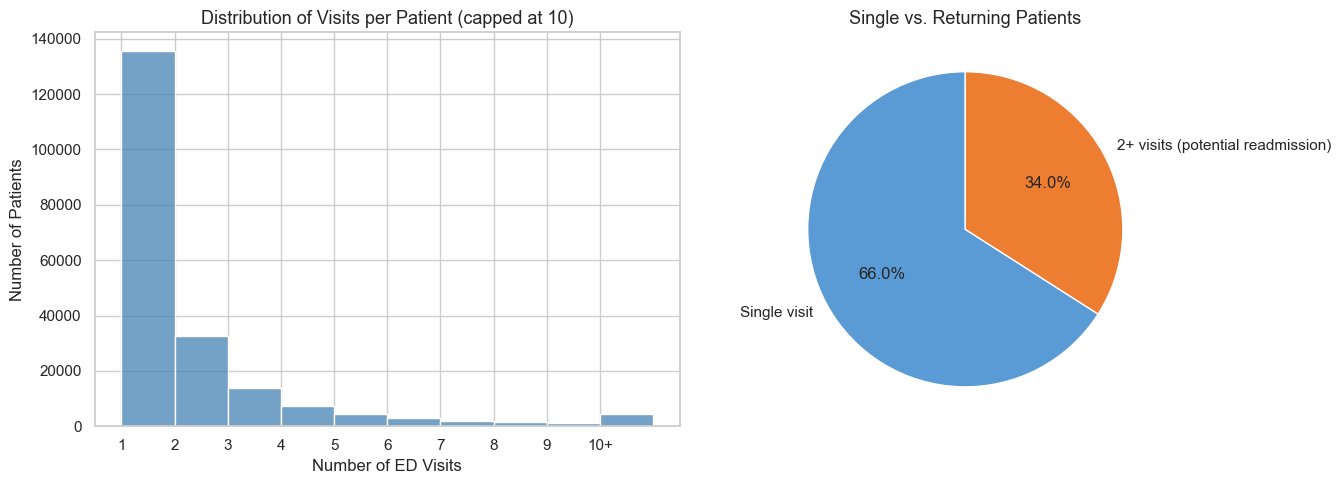

In [5]:
# Count number of visits per patient
visits_per_patient = df_edstays.groupby('subject_id')['stay_id'].count().reset_index()
visits_per_patient.columns = ['subject_id', 'num_visits']

total_patients = len(visits_per_patient)
single_visit = (visits_per_patient['num_visits'] == 1).sum()
multiple_visits = (visits_per_patient['num_visits'] > 1).sum()

print(f"Total unique patients:          {total_patients:,}")
print(f"Patients with only 1 visit:     {single_visit:,}  ({100*single_visit/total_patients:.1f}%)")
print(f"Patients with 2+ visits:        {multiple_visits:,}  ({100*multiple_visits/total_patients:.1f}%)")

# Distribution of number of visits per patient
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram capped at 10 for readability
visits_capped = visits_per_patient['num_visits'].clip(upper=10)
sns.histplot(visits_capped, bins=range(1, 12), ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Visits per Patient (capped at 10)', fontsize=13)
axes[0].set_xlabel('Number of ED Visits')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xticks(range(1, 11))
axes[0].set_xticklabels([str(i) if i < 10 else '10+' for i in range(1, 11)])

# Right: Pie chart — 1 visit vs multiple visits
axes[1].pie(
    [single_visit, multiple_visits],
    labels=['Single visit', '2+ visits (potential readmission)'],
    autopct='%1.1f%%',
    colors=['#5B9BD5', '#ED7D31'],
    startangle=90
)
axes[1].set_title('Single vs. Returning Patients', fontsize=13)

plt.tight_layout()
plt.show()

---
## 2. Time Between Consecutive Visits (Days to Readmission)

For patients with multiple visits, we calculate: **how many days passed between the discharge (`outtime`) of one visit and the arrival (`intime`) of the next visit?**  
This distribution is the key to choosing the right readmission threshold.

In [6]:
# Sort by patient and arrival time
df_sorted = df_edstays.sort_values(['subject_id', 'intime'])

# For each patient, shift outtime to get the previous discharge time
df_sorted['prev_outtime'] = df_sorted.groupby('subject_id')['outtime'].shift(1)

# Calculate the gap in days between discharge and next admission
df_sorted['days_to_readmission'] = (
    df_sorted['intime'] - df_sorted['prev_outtime']
).dt.total_seconds() / 86400  # convert seconds -> days

# Keep only the rows that actually have a previous visit (i.e., readmission candidates)
df_gaps = df_sorted[df_sorted['days_to_readmission'].notna()].copy()

print(f"Total readmission events (consecutive visit pairs): {len(df_gaps):,}")
print(f"\nSummary statistics of days to readmission:")
display(df_gaps['days_to_readmission'].describe().rename({
    'count': 'Pairs (n)',
    'mean': 'Mean (days)',
    'std': 'Std Dev (days)',
    'min': 'Min (days)',
    '25%': 'Q1 (days)',
    '50%': 'Median (days)',
    '75%': 'Q3 (days)',
    'max': 'Max (days)'
}).to_frame())

Total readmission events (consecutive visit pairs): 219,583

Summary statistics of days to readmission:


,days_to_readmission
Pairs (n),219583.000000
Mean (days),271.872145
Std Dev (days),409.259277
Min (days),-0.730556
Q1 (days),21.051481
Median (days),95.823611
Q3 (days),341.493403
Max (days),2928.562500


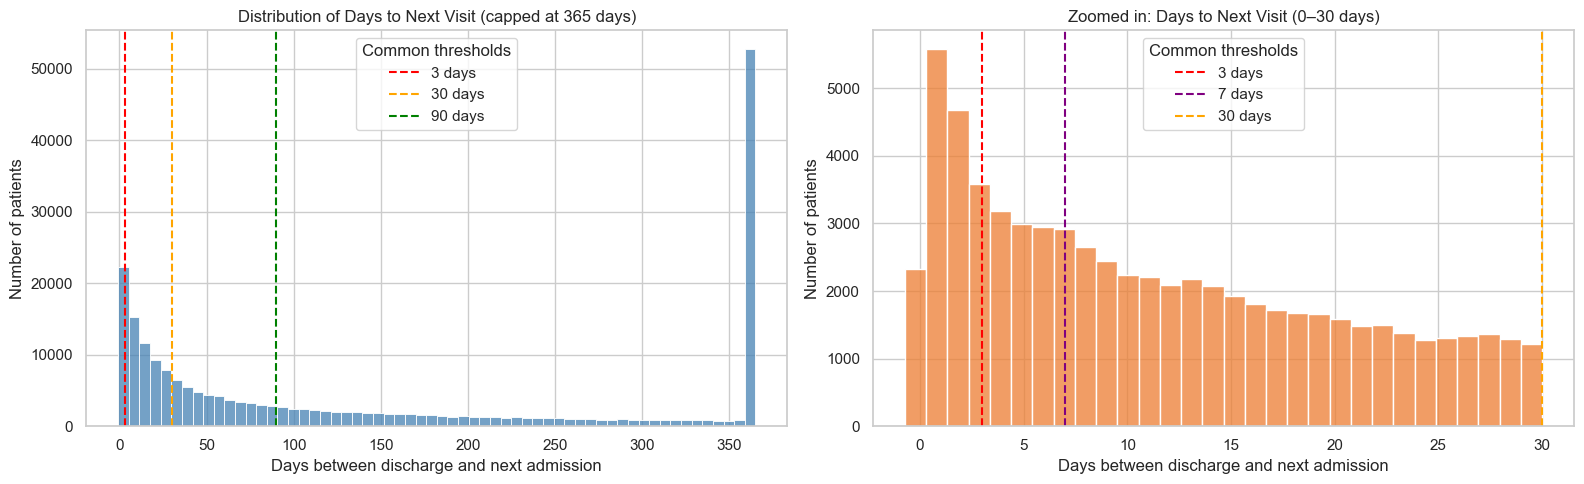

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Full distribution (log scale on y-axis to see the tail)
sns.histplot(df_gaps['days_to_readmission'].clip(upper=365), bins=60, ax=axes[0], color='steelblue')
axes[0].axvline(x=3,  color='red',    linestyle='--', linewidth=1.5, label='3 days')
axes[0].axvline(x=30, color='orange', linestyle='--', linewidth=1.5, label='30 days')
axes[0].axvline(x=90, color='green',  linestyle='--', linewidth=1.5, label='90 days')
axes[0].set_title('Distribution of Days to Next Visit (capped at 365 days)', fontsize=12)
axes[0].set_xlabel('Days between discharge and next admission')
axes[0].set_ylabel('Number of patients')
axes[0].legend(title='Common thresholds')

# Right: Zoomed in on the first 30 days (where most readmissions happen)
early = df_gaps[df_gaps['days_to_readmission'] <= 30]
sns.histplot(early['days_to_readmission'], bins=30, ax=axes[1], color='#ED7D31')
axes[1].axvline(x=3,  color='red',    linestyle='--', linewidth=1.5, label='3 days')
axes[1].axvline(x=7,  color='purple', linestyle='--', linewidth=1.5, label='7 days')
axes[1].axvline(x=30, color='orange', linestyle='--', linewidth=1.5, label='30 days')
axes[1].set_title('Zoomed in: Days to Next Visit (0–30 days)', fontsize=12)
axes[1].set_xlabel('Days between discharge and next admission')
axes[1].set_ylabel('Number of patients')
axes[1].legend(title='Common thresholds')

plt.tight_layout()
plt.show()

---
## 3. Readmission Rate by Threshold

Let's quantify exactly how many **first stays** would be labeled as `readmitted = 1` under different time thresholds:  
choosing a threshold that is too tight (e.g. 3 days) gives us very few positive examples;  
too wide (e.g. 90 days) might include patients who simply had a new unrelated condition.

In [8]:
# Evaluate different readmission thresholds
thresholds = [3, 7, 14, 30, 60, 90]
total_first_stays = len(df_edstays)

rows = []
for t in thresholds:
    n_readmitted = (df_gaps['days_to_readmission'] <= t).sum()
    pct = 100 * n_readmitted / total_first_stays
    rows.append({
        'Threshold (days)': t,
        'Readmitted stays': f"{n_readmitted:,}",
        'Total stays': f"{total_first_stays:,}",
        'Readmission rate (%)': f"{pct:.2f}%"
    })

display(pd.DataFrame(rows))

,Threshold (days),Readmitted stays,Total stays,Readmission rate (%)
0,3,"15,152","425,087",3.56%
1,7,"27,133","425,087",6.38%
2,14,"43,006","425,087",10.12%
3,30,"66,564","425,087",15.66%
4,60,"91,356","425,087",21.49%
5,90,"107,238","425,087",25.23%


---
## 4. Chosen Threshold & Target Column Creation

Based on the distribution above, we choose a threshold of **`X days`** (fill in after reviewing the table).  
We then create the binary target column `readmitted`: 
- `1` → the patient returned to the ED within the threshold after being discharged  
- `0` → the patient did not return within the threshold

Threshold: 30 days
Readmitted (1):     66,564  (15.66%)
Not readmitted (0): 358,523  (84.34%)


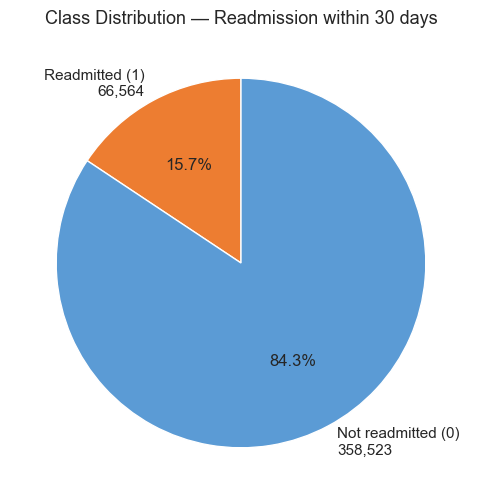

In [9]:
# Set the threshold here after reviewing Section 3:
THRESHOLD_DAYS = 30

# For each stay, check if the NEXT visit happened within the threshold
df_edstays_sorted = df_edstays.sort_values(['subject_id', 'intime']).copy()

# Compute 'days_to_next_visit' for each row (using next intime, not prev outtime)
df_edstays_sorted['next_intime'] = df_edstays_sorted.groupby('subject_id')['intime'].shift(-1)
df_edstays_sorted['days_to_next_visit'] = (
    df_edstays_sorted['next_intime'] - df_edstays_sorted['outtime']
).dt.total_seconds() / 86400

# Create binary target: 1 if next visit is within threshold, 0 otherwise
df_edstays_sorted['readmitted'] = (
    df_edstays_sorted['days_to_next_visit'] <= THRESHOLD_DAYS
).astype(int)

# Summary
n_readmitted = df_edstays_sorted['readmitted'].sum()
n_total = len(df_edstays_sorted)
print(f"Threshold: {THRESHOLD_DAYS} days")
print(f"Readmitted (1):     {n_readmitted:,}  ({100*n_readmitted/n_total:.2f}%)")
print(f"Not readmitted (0): {n_total - n_readmitted:,}  ({100*(n_total - n_readmitted)/n_total:.2f}%)")

# Pie chart of class balance
plt.figure(figsize=(6, 6))
plt.pie(
    [n_readmitted, n_total - n_readmitted],
    labels=[f'Readmitted (1)\n{n_readmitted:,}', f'Not readmitted (0)\n{n_total - n_readmitted:,}'],
    autopct='%1.1f%%',
    colors=['#ED7D31', '#5B9BD5'],
    startangle=90
)
plt.title(f'Class Distribution — Readmission within {THRESHOLD_DAYS} days', fontsize=13)
plt.show()

# Save the result for the next notebook
df_edstays_sorted.to_csv("edstays_with_target.csv", index=False)

### Conclusions — Threshold Analysis

From the actual MIMIC-IV-ED data, we can draw the following conclusions:

**1. One in three patients returns to the ED (34%).**  
Of the 205,504 unique patients in this dataset, **135,552 (66%) visited the ED exactly once**, while **69,952 (34%) returned at least once**. This confirms that readmission is a frequent and clinically relevant phenomenon in this population.

**2. The distribution of days-to-readmission is heavily right-skewed.**  
The median time between consecutive visits is ~95.8 days, but the mean is ~271.9 days — a clear sign of a very long tail. The Q1 is just 21 days, meaning 25% of returning patients come back within 3 weeks of their last discharge. There are even cases with **negative gaps (-0.73 days)**, which suggests some transitions directly between stays (e.g., transfers).

**3. Threshold decision: 30 days.**  
Looking at the threshold table:
- **3 days** → 15,152 readmissions (3.56%) — too few positives for a model to learn from.
- **30 days** → 66,564 readmissions (15.66%) — clinically standard and gives a workable class ratio of ~1:6.  
- **90 days** → 107,238 readmissions (25.23%) — likely includes many new, unrelated conditions rather than preventable readmissions.

A 30-day threshold aligns with standard clinical policy (e.g., CMS readmission programs) and provides the best balance between **clinical relevance** and **dataset balance** for training the predictive model.
